# 5-Fold Stratified Cross-Validation

This experiment evaluates the stability of the machine-learning models using 5-fold stratified cross-validation.

The models evaluated are:

- Logistic Regression
- Linear SVM
- Random Forest

The experiment uses the binary-labeled subset of the final security review dataset, excluding uncertain label 2 comments.

The same TF-IDF representation and model configurations used in the previous model comparison experiment are retained.

The purpose of this experiment is to determine whether model performance remains reasonably consistent across different train/validation partitions rather than relying on a single 80/20 train-test split.

In [1]:
import os
import time

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from IPython.display import display

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

DATA_PATH = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed",
    "final_security.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (9230, 13)


,comment_id,comment,repo,language,pr_id,c_id,matched_strong,matched_weak,security_categories,candidate_score,indicator_strength,manual_label,review_notes
0,208849771,Should not `ansible.utils.encrypt.random_passw...,ansible,Python,21225735,1095841089,NaN,password; encryption,authentication; cryptography,2,weak,0,"Keyword appears while describing, implementing..."
1,258431281,These routes are quite a lot to copy in here. ...,AspNetCore,NaN,56148722,1303642745,NaN,authorization; authorize,authorization,2,weak,0,"Keyword appears while describing, implementing..."
2,269690752,slow-tests does also contain ssl-certificate r...,chainweb-node,Haskell,58703769,1341744273,NaN,ssl; certificate,cryptography,2,weak,0,"Keyword appears while describing, implementing..."
3,195074858,minikube start --bootstrapper localkube --extr...,service-manager,NaN,39143713,1005582331,NaN,authorization; authorize,authorization,2,weak,0,"Keyword appears while describing, implementing..."
4,224629987,There might be some confusion. I ran this cod...,hail,Scala,47236096,1161354134,NaN,secret; session,authentication; secrets,2,weak,1,Comment explicitly describes a security weakne...


In [3]:
binary_df = df[df["manual_label"].isin([0, 1])].copy()

binary_df["actual_label"] = binary_df["manual_label"].astype(int)

print("Binary dataset shape:", binary_df.shape)

print("\nClass distribution:")
display(
    binary_df["actual_label"]
    .value_counts()
    .sort_index()
    .rename(index={
        0: "Not security-related",
        1: "Security-related"
    })
)

Binary dataset shape: (9147, 14)

Class distribution:


actual_label
Not security-related    6119
Security-related        3028
Name: count, dtype: int64

In [4]:
X = binary_df["comment"].fillna("").astype(str)
y = binary_df["actual_label"]

print("Number of samples:", len(X))
print("Number of labels:", len(y))

Number of samples: 9147
Number of labels: 9147


In [5]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

print("TF-IDF configuration:")
print(tfidf)

TF-IDF configuration:
TfidfVectorizer(max_df=0.95, min_df=2, ngram_range=(1, 2), stop_words='english',
                sublinear_tf=True)


In [6]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

print("Models defined:")
for name in models:
    print("-", name)

Models defined:
- Logistic Regression
- Linear SVM
- Random Forest


In [7]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Cross-validation configuration:")
print("Number of folds:", cv.n_splits)
print("Shuffle:", cv.shuffle)
print("Random state:", cv.random_state)

Cross-validation configuration:
Number of folds: 5
Shuffle: True
Random state: 42


In [8]:
results = []

for model_name, model in models.items():

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    for fold_number, (train_idx, val_idx) in enumerate(
        cv.split(X, y),
        start=1
    ):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        pipeline = Pipeline([
            ("tfidf", TfidfVectorizer(
                lowercase=True,
                stop_words="english",
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True
            )),
            ("model", model)
        ])

        start_time = time.time()

        pipeline.fit(X_train, y_train)

        training_time = time.time() - start_time

        start_time = time.time()

        y_pred = pipeline.predict(X_val)

        prediction_time = time.time() - start_time

        results.append({
            "model": model_name,
            "fold": fold_number,
            "accuracy": accuracy_score(y_val, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_val, y_pred),
            "precision": precision_score(
                y_val,
                y_pred,
                zero_division=0
            ),
            "recall": recall_score(
                y_val,
                y_pred,
                zero_division=0
            ),
            "f1_score": f1_score(
                y_val,
                y_pred,
                zero_division=0
            ),
            "training_time_seconds": training_time,
            "prediction_time_seconds": prediction_time
        })

        print(
            f"Fold {fold_number}: "
            f"Accuracy={results[-1]['accuracy']:.4f}, "
            f"F1={results[-1]['f1_score']:.4f}"
        )

results_df = pd.DataFrame(results)

print("\nCross-validation completed.")


Logistic Regression
Fold 1: Accuracy=0.9678, F1=0.9496
Fold 2: Accuracy=0.9650, F1=0.9449
Fold 3: Accuracy=0.9738, F1=0.9590
Fold 4: Accuracy=0.9606, F1=0.9379
Fold 5: Accuracy=0.9612, F1=0.9388

Linear SVM
Fold 1: Accuracy=0.9765, F1=0.9636
Fold 2: Accuracy=0.9710, F1=0.9547
Fold 3: Accuracy=0.9787, F1=0.9671
Fold 4: Accuracy=0.9666, F1=0.9475
Fold 5: Accuracy=0.9710, F1=0.9548

Random Forest
Fold 1: Accuracy=0.9678, F1=0.9493
Fold 2: Accuracy=0.9623, F1=0.9399
Fold 3: Accuracy=0.9699, F1=0.9527
Fold 4: Accuracy=0.9584, F1=0.9338
Fold 5: Accuracy=0.9590, F1=0.9347

Cross-validation completed.


In [9]:
display(
    results_df[
        [
            "model",
            "fold",
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall",
            "f1_score"
        ]
    ]
)

,model,fold,accuracy,balanced_accuracy,precision,recall,f1_score
0,Logistic Regression,1,0.967760,0.955069,0.984071,0.917492,0.949616
1,Logistic Regression,2,0.965027,0.950111,0.987410,0.905941,0.944923
2,Logistic Regression,3,0.973756,0.962420,0.991182,0.928926,0.959044
3,Logistic Regression,4,0.960634,0.945093,0.980180,0.899174,0.937931
4,Logistic Regression,5,0.961181,0.945582,0.981982,0.899340,0.938846
5,Linear SVM,1,0.976503,0.967021,0.989565,0.938944,0.963590
6,Linear SVM,2,0.971038,0.958354,0.991119,0.920792,0.954662
7,Linear SVM,3,0.978677,0.970694,0.987931,0.947107,0.967089
8,Linear SVM,4,0.966648,0.952094,0.989209,0.909091,0.947459
9,Linear SVM,5,0.971022,0.959184,0.987654,0.924092,0.954817


In [10]:
summary_df = (
    results_df
    .groupby("model")
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),

        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_std=("balanced_accuracy", "std"),

        precision_mean=("precision", "mean"),
        precision_std=("precision", "std"),

        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),

        f1_mean=("f1_score", "mean"),
        f1_std=("f1_score", "std"),

        training_time_mean=("training_time_seconds", "mean"),
        prediction_time_mean=("prediction_time_seconds", "mean")
    )
    .reset_index()
)

display(summary_df)

,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,training_time_mean,prediction_time_mean
0,Linear SVM,0.972778,0.004805,0.961470,0.007395,0.989096,0.001393,0.928005,0.015080,0.957523,0.007828,0.126307,0.022090
1,Logistic Regression,0.965672,0.005378,0.951655,0.007244,0.984965,0.004394,0.910174,0.012860,0.946072,0.008670,0.139055,0.022295
2,Random Forest,0.963485,0.005166,0.946934,0.007438,0.990878,0.002945,0.897954,0.014258,0.942090,0.008542,0.809563,0.060017


In [11]:
report_df = summary_df.copy()

report_df["accuracy"] = (
    report_df["accuracy_mean"].round(4).astype(str)
    + " ± "
    + report_df["accuracy_std"].round(4).astype(str)
)

report_df["balanced_accuracy"] = (
    report_df["balanced_accuracy_mean"].round(4).astype(str)
    + " ± "
    + report_df["balanced_accuracy_std"].round(4).astype(str)
)

report_df["precision"] = (
    report_df["precision_mean"].round(4).astype(str)
    + " ± "
    + report_df["precision_std"].round(4).astype(str)
)

report_df["recall"] = (
    report_df["recall_mean"].round(4).astype(str)
    + " ± "
    + report_df["recall_std"].round(4).astype(str)
)

report_df["f1_score"] = (
    report_df["f1_mean"].round(4).astype(str)
    + " ± "
    + report_df["f1_std"].round(4).astype(str)
)

report_df = report_df[
    [
        "model",
        "accuracy",
        "balanced_accuracy",
        "precision",
        "recall",
        "f1_score"
    ]
]

display(report_df)

,model,accuracy,balanced_accuracy,precision,recall,f1_score
0,Linear SVM,0.9728 ± 0.0048,0.9615 ± 0.0074,0.9891 ± 0.0014,0.928 ± 0.0151,0.9575 ± 0.0078
1,Logistic Regression,0.9657 ± 0.0054,0.9517 ± 0.0072,0.985 ± 0.0044,0.9102 ± 0.0129,0.9461 ± 0.0087
2,Random Forest,0.9635 ± 0.0052,0.9469 ± 0.0074,0.9909 ± 0.0029,0.898 ± 0.0143,0.9421 ± 0.0085


In [12]:
fold_stability = (
    results_df
    .groupby("model")["f1_score"]
    .agg(
        minimum="min",
        maximum="max",
        mean="mean",
        standard_deviation="std"
    )
    .reset_index()
)

display(fold_stability)

,model,minimum,maximum,mean,standard_deviation
0,Linear SVM,0.947459,0.967089,0.957523,0.007828
1,Logistic Regression,0.937931,0.959044,0.946072,0.008670
2,Random Forest,0.933798,0.952709,0.942090,0.008542


In [13]:
OUTPUT_DIR = os.path.join(
    PROJECT_ROOT,
    "data",
    "results"
)

os.makedirs(OUTPUT_DIR, exist_ok=True)

results_path = os.path.join(
    OUTPUT_DIR,
    "cross_validation_results.csv"
)

summary_path = os.path.join(
    OUTPUT_DIR,
    "cross_validation_summary.csv"
)

results_df.to_csv(
    results_path,
    index=False
)

summary_df.to_csv(
    summary_path,
    index=False
)

print("Saved:")
print(results_path)
print(summary_path)

Saved:
/Users/mustafaahmed/Documents/Security Code Review Analysis/data/results/cross_validation_results.csv
/Users/mustafaahmed/Documents/Security Code Review Analysis/data/results/cross_validation_summary.csv


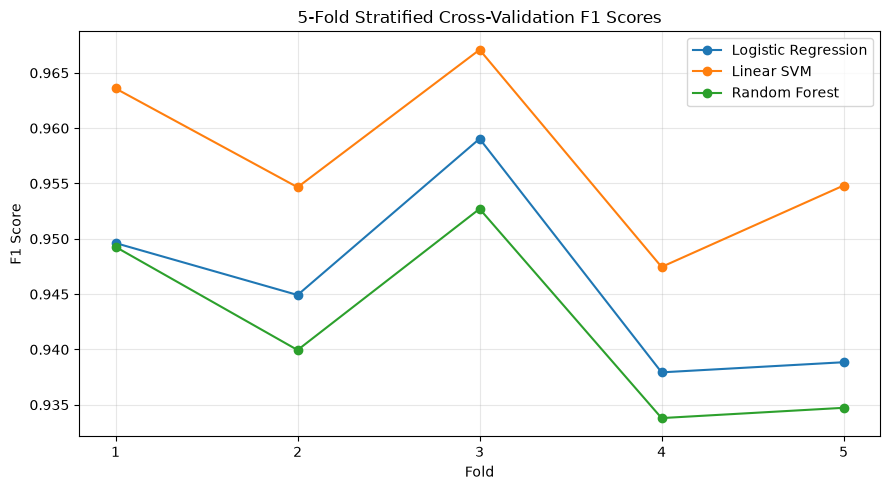

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

for model_name in results_df["model"].unique():

    model_data = results_df[
        results_df["model"] == model_name
    ]

    plt.plot(
        model_data["fold"],
        model_data["f1_score"],
        marker="o",
        label=model_name
    )

plt.xlabel("Fold")
plt.ylabel("F1 Score")
plt.title("5-Fold Stratified Cross-Validation F1 Scores")
plt.xticks([1, 2, 3, 4, 5])
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()